# Automated Wafer Defect Pattern Classification  
**Contributors:** Jordan Torske, Bruce Gillis

## Executive Summary

**Goal:**  
Classify semiconductor wafer defect patterns from wafer map images.

**Approach:**  
- Trained **ResNet-18 from scratch** and **fine-tuned a pre-trained ViT-Tiny**
- Applied extensive **data augmentation** and **regularization**
- Addressed **severe class imbalance** through subsampling and per-class analysis

**Key Results:**  
- **ViT-Tiny outperformed ResNet-18** on most defect classes  
- CNN struggled with **minority and globally-distributed defects** (e.g., *Random*, *Scratch*)  
- Transformer showed **stronger generalization** due to global attention mechanisms

**Takeaway:**  
CNNs excel at local texture patterns, while transformers better capture global defect structures.



## Key Engineering Decisions

- **ResNet-18 trained from scratch** to establish a CNN baseline without transfer learning bias
- **ViT-Tiny fine-tuned from ImageNet** to evaluate transformer generalization on global defect patterns
- **Aggressive data augmentation** applied due to rotational and translational invariance of wafer maps
- **Label smoothing and weight decay** used to reduce overconfidence on dominant classes
- **Per-class evaluation** emphasized due to severe class imbalance in real manufacturing data


In [ ]:
# ============================================================
# INSTALL EXTERNAL DEPENDENCIES
# ============================================================
# timm provides the ViT-Tiny model we'll fine-tune.

!pip install -q timm

In [ ]:
# ============================================================
# IMPORTS & GLOBAL CONFIGURATION
# ============================================================

import os
import random
from collections import Counter
from typing import Tuple, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
from torchvision.models import resnet18

import timm

# ------------------------------------------------------------
# REPRODUCIBILITY
# ------------------------------------------------------------

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Use GPU if available
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ------------------------------------------------------------
# CONFIGURATION PARAMETERS
# ------------------------------------------------------------

# Subsample per defect class to keep training time manageable
MAX_SAMPLES_PER_CLASS = 3000   # Cap samples per class so training fits in Colab time/VRAM, while still leaving enough data for each defect type.

BATCH_SIZE = 64                # Typical mini-batch size that balances GPU utilization and memory usage on a Colab GPU.

NUM_WORKERS = 2                # Number of DataLoader workers; 2 is usually safe in Colab without hitting multiprocessing issues.

NUM_EPOCHS_RESNET = 10          # More epochs for the from-scratch ResNet-18 since it starts with random weights and needs longer to learn.

NUM_EPOCHS_VIT = 5             # Fewer epochs for ViT-Tiny because it is pre-trained and usually converges faster during fine-tuning.

IMAGE_SIZE = 224               # Input resolution expected by both ResNet-18 and ViT-Tiny.

Using device: cuda


## 1. Dataset Setup (Mixed-Type Wafer Defect Dataset - `.npz` Format)

For this project, we use the **Mixed-Type Wafer Defect Datasets** available on Kaggle.

This dataset provides wafer maps already converted into numerical array form and grouped into
eight defect pattern classes:

**Defect Classes**
- Center  
- Donut  
- Edge-Loc  
- Edge-Ring  
- Loc  
- Random  
- Scratch  
- Near-full

**Dataset File:**
- `Wafer_Map_Datasets.npz`

This file contains:
- `arr_0` → wafer map images (NumPy arrays of shape `(N, 52, 52)`), encoded with grayscale values.
- `arr_1` → one-hot-encoded defect labels `(N, 8)`.

The `.npz` format makes loading extremely fast and avoids the heavy preprocessing required for
other datasets.  

Please upload your `kaggle.json` file below so the notebook can automatically download the dataset.


In [ ]:
# ============================================================
# DOWNLOAD MIXED-TYPE WAFER DEFECT DATASET
# ============================================================
# How to get kaggle.json:
# 1. Go to: https://www.kaggle.com/settings > API > Create Legacy API Key
# 2. This downloads a file called "kaggle.json"
# 3. Upload that file when prompted below

!pip install kaggle --quiet

from google.colab import files
print("Upload your kaggle.json (Kaggle > Settings > API)")
files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

print("Downloading wafer defect dataset...")
!kaggle datasets download -d co1d7era/mixedtype-wafer-defect-datasets --force --quiet

print("Extracting files...")
!unzip -o -q mixedtype-wafer-defect-datasets.zip

print("Dataset ready!")


Upload your kaggle.json (Kaggle > Settings > API)


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/co1d7era/mixedtype-wafer-defect-datasets
License(s): copyright-authors
Extracting files...
Dataset ready!


Loaded wafer maps: (38015, 52, 52)
Loaded labels: (38015, 8)
CNN-ready shape: (38015, 52, 52, 1)
Flattened shape: (38015, 2704)
Train shapes: (30412, 52, 52, 1) (30412, 8)
Test shapes: (7603, 52, 52, 1) (7603, 8)


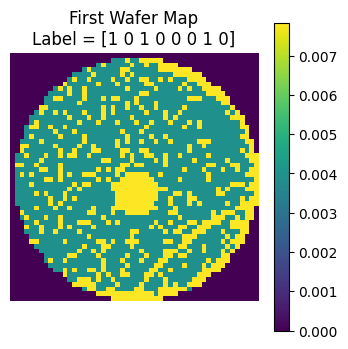

,wafer_map_shape,label_vector
0,"(52, 52)","[1, 0, 1, 0, 0, 0, 1, 0]"
1,"(52, 52)","[1, 0, 1, 0, 0, 0, 1, 0]"
2,"(52, 52)","[1, 0, 1, 0, 0, 0, 1, 0]"
3,"(52, 52)","[1, 0, 1, 0, 0, 0, 1, 0]"
4,"(52, 52)","[1, 0, 1, 0, 0, 0, 1, 0]"


In [ ]:
# ============================================================
# LOAD & PREPROCESS: MIXED-TYPE WAFER DEFECT DATASET (.NPZ)
# ============================================================


npz_path = "Wafer_Map_Datasets.npz"
data = np.load(npz_path, allow_pickle=True)

wafer_maps = data["arr_0"]
labels = data["arr_1"]

print("Loaded wafer maps:", wafer_maps.shape)
print("Loaded labels:", labels.shape)

wafer_maps = wafer_maps.astype("float32") / 255.0

wafer_maps_cnn = wafer_maps[..., np.newaxis]
wafer_maps_flat = wafer_maps.reshape(len(wafer_maps), -1)

print("CNN-ready shape:", wafer_maps_cnn.shape)
print("Flattened shape:", wafer_maps_flat.shape)

X_train_cnn, X_test_cnn, y_train, y_test = train_test_split(
    wafer_maps_cnn, labels, test_size=0.2, random_state=42, shuffle=True
)

X_train_flat, X_test_flat, _, _ = train_test_split(
    wafer_maps_flat, labels, test_size=0.2, random_state=42, shuffle=True
)

print("Train shapes:", X_train_cnn.shape, y_train.shape)
print("Test shapes:", X_test_cnn.shape, y_test.shape)

df_preview = pd.DataFrame({
    "wafer_map_shape": [x.shape for x in wafer_maps[:5]],
    "label_vector": labels[:5].tolist()
})

plt.figure(figsize=(4, 4))
plt.imshow(wafer_maps[0], cmap="viridis")
plt.title(f"First Wafer Map\nLabel = {labels[0]}")
plt.colorbar()
plt.axis("off")
plt.show()

df_preview


In [ ]:
# ============================================================
# SUBSAMPLE TO LIMIT PER-CLASS SIZE (FOR FASTER TRAINING)
# ============================================================

CLASS_NAMES = [
    "Center", "Donut", "Edge-Loc", "Edge-Ring",
    "Loc", "Random", "Scratch", "Near-full"
]

def subsample_per_class_arrays(X_cnn, X_flat, Y, max_per_class, seed=SEED):
    if max_per_class is None:
        return X_cnn, X_flat, Y

    rng = np.random.RandomState(seed)

    primary_labels = np.argmax(Y, axis=1)
    all_indices = np.arange(len(Y))

    selected_indices = []

    for c in np.unique(primary_labels):
        cls_indices = all_indices[primary_labels == c]

        if max_per_class is not None and len(cls_indices) > max_per_class:
            cls_indices = rng.choice(cls_indices, size=max_per_class, replace=False)

        selected_indices.append(cls_indices)

    selected_indices = np.concatenate(selected_indices)
    rng.shuffle(selected_indices)

    X_cnn_sub = X_cnn[selected_indices]
    X_flat_sub = X_flat[selected_indices]
    Y_sub = Y[selected_indices]

    primary_sub = np.argmax(Y_sub, axis=1)
    counts = Counter(primary_sub)
    print("Class counts after subsampling (by primary label):")
    for idx, count in sorted(counts.items()):
        name = CLASS_NAMES[idx] if idx < len(CLASS_NAMES) else f"class_{idx}"
        print(f"  {idx} ({name}): {count}")

    return X_cnn_sub, X_flat_sub, Y_sub


X_train_cnn_bal, X_train_flat_bal, y_train_bal = subsample_per_class_arrays(
    X_train_cnn, X_train_flat, y_train, MAX_SAMPLES_PER_CLASS
)

print("\nFinal balanced training shapes:")
print("X_train_cnn_bal :", X_train_cnn_bal.shape)
print("X_train_flat_bal:", X_train_flat_bal.shape)
print("y_train_bal     :", y_train_bal.shape)


Class counts after subsampling (by primary label):
  0 (Center): 3000
  1 (Donut): 3000
  2 (Edge-Loc): 3000
  3 (Edge-Ring): 3000
  4 (Loc): 1590
  5 (Random): 115
  6 (Scratch): 815
  7 (Near-full): 687

Final balanced training shapes:
X_train_cnn_bal : (15207, 52, 52, 1)
X_train_flat_bal: (15207, 2704)
y_train_bal     : (15207, 8)


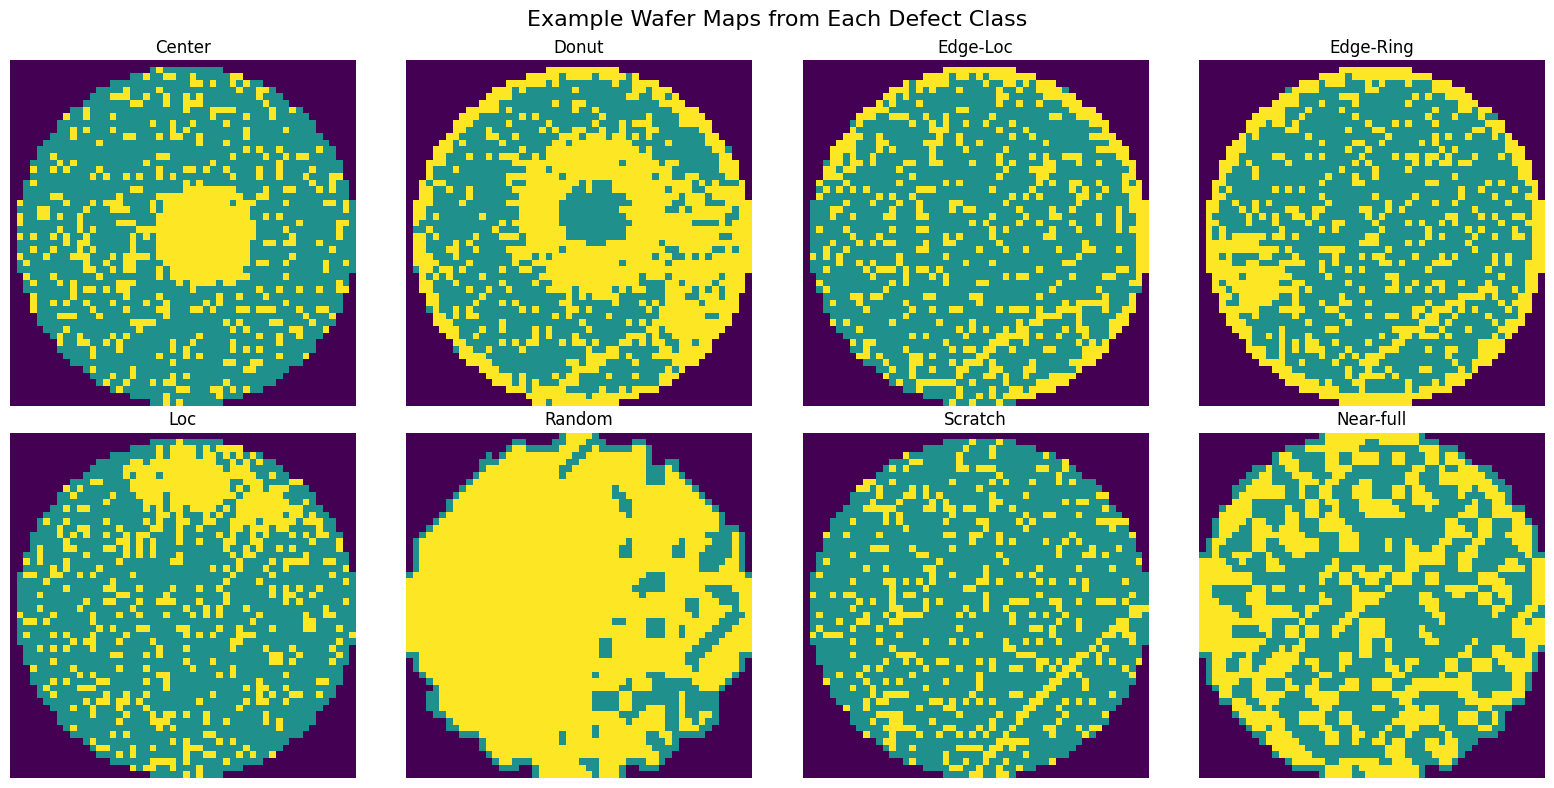

In [ ]:
# ============================================================
# VISUALIZE SAMPLE WAFER MAPS
# ============================================================

CLASS_NAMES = [
    "Center", "Donut", "Edge-Loc", "Edge-Ring",
    "Loc", "Random", "Scratch", "Near-full"
]

y_train_primary = np.argmax(y_train_bal, axis=1)

plt.figure(figsize=(16, 8))

for class_idx, class_name in enumerate(CLASS_NAMES):
    indices = np.where(y_train_primary == class_idx)[0]

    if len(indices) == 0:
        print(f"No samples found for class {class_name}, skipping.")
        continue

    i = np.random.choice(indices)
    wafer_img = X_train_cnn_bal[i].squeeze()

    plt.subplot(2, 4, class_idx + 1)
    plt.imshow(wafer_img, cmap="viridis")
    plt.title(class_name)
    plt.axis("off")

plt.suptitle("Example Wafer Maps from Each Defect Class", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# TORCH DATASET & TRANSFORMS
# ============================================================

NUM_CLASSES = 8

CLASS_NAMES = [
    "Center", "Donut", "Edge-Loc", "Edge-Ring",
    "Loc", "Random", "Scratch", "Near-full"
]

train_transform = T.Compose([
    T.Resize(256),

    # Standardize final input size while keeping wafer centered
    T.CenterCrop(IMAGE_SIZE),

    # Wafer maps are symmetric → flips improve invariance
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),

    # Small rotations help with slight wafer misalignment
    T.RandomRotation(10),

    # Adds robustness to low-contrast or blurry defects (e.g., Scratch)
    T.RandomApply([T.GaussianBlur(3)], p=0.3),

    # Helps model handle brightness/contrast variations in wafer images
    T.ColorJitter(brightness=0.15, contrast=0.15),

    # Small translations improve Loc vs Edge-Loc separation
    T.RandomAffine(
        degrees=10,
        translate=(0.05, 0.05),
    ),

    # Normalize grayscale-mapped 3-channel tensor
    T.Normalize(mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5]),
])



eval_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.Normalize(mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5]),
])

class WaferMapDataset(Dataset):
    def __init__(self, images: np.ndarray, labels: np.ndarray, transform=None):
        assert images.shape[0] == labels.shape[0], "Mismatched image/label lengths"
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self) -> int:
        return self.images.shape[0]

    def __getitem__(self, idx: int):
        img = self.images[idx]
        label_vec = self.labels[idx]

        img = torch.from_numpy(img).float()
        img = img.permute(2, 0, 1)

        img = img.repeat(3, 1, 1)

        target = int(np.argmax(label_vec))

        if self.transform is not None:
            img = self.transform(img)

        return img, target

train_dataset = WaferMapDataset(X_train_cnn_bal, y_train_bal, transform=train_transform)
test_dataset  = WaferMapDataset(X_test_cnn,      y_test,      transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")


Train batches: 238, Test batches: 119


In [ ]:
# ============================================================
# TRAINING & EVALUATION HELPERS
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, targets in loader:
        imgs = imgs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, targets in loader:
            imgs = imgs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            outputs = model(imgs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


In [ ]:
# ============================================================
# TUNED MODEL 1: RESNET-18 (FROM SCRATCH, REGULARIZED)
# ============================================================

model_resnet = resnet18(weights=None)
in_features = model_resnet.fc.in_features
model_resnet.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(in_features, NUM_CLASSES),
)

model_resnet = model_resnet.to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam(
    model_resnet.parameters(),
    lr=5e-4,
    weight_decay=5e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS_RESNET
)

best_resnet_acc = 0.0
history_resnet = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": [],
}

for epoch in range(1, NUM_EPOCHS_RESNET + 1):
    train_loss, train_acc = train_one_epoch(
        model_resnet, train_loader, optimizer, criterion, device=DEVICE
    )
    test_loss, test_acc = evaluate(
        model_resnet, test_loader, criterion, device=DEVICE
    )

    history_resnet["train_loss"].append(train_loss)
    history_resnet["train_acc"].append(train_acc)
    history_resnet["test_loss"].append(test_loss)
    history_resnet["test_acc"].append(test_acc)

    scheduler.step()

    if test_acc > best_resnet_acc:
        best_resnet_acc = test_acc
        torch.save(model_resnet.state_dict(), "resnet18_wafer_tuned_best.pth")

    print(
        f"[Tuned ResNet Epoch {epoch:02d}/{NUM_EPOCHS_RESNET}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}"
    )

print(f"\n✅ Best Tuned ResNet-18 Test Accuracy: {best_resnet_acc:.4f}")


[Tuned ResNet Epoch 01/10] Train Loss: 1.0859 | Train Acc: 0.6834 | Test Loss: 3.7954 | Test Acc: 0.0548
[Tuned ResNet Epoch 02/10] Train Loss: 0.7832 | Train Acc: 0.8649 | Test Loss: 5.0399 | Test Acc: 0.0235
[Tuned ResNet Epoch 03/10] Train Loss: 0.7322 | Train Acc: 0.8995 | Test Loss: 2.8954 | Test Acc: 0.1088
[Tuned ResNet Epoch 04/10] Train Loss: 0.6729 | Train Acc: 0.9314 | Test Loss: 3.9135 | Test Acc: 0.0243
[Tuned ResNet Epoch 05/10] Train Loss: 0.6370 | Train Acc: 0.9423 | Test Loss: 2.9291 | Test Acc: 0.0235
[Tuned ResNet Epoch 06/10] Train Loss: 0.6103 | Train Acc: 0.9511 | Test Loss: 2.6018 | Test Acc: 0.0235
[Tuned ResNet Epoch 07/10] Train Loss: 0.5927 | Train Acc: 0.9609 | Test Loss: 3.9146 | Test Acc: 0.0235
[Tuned ResNet Epoch 08/10] Train Loss: 0.5737 | Train Acc: 0.9668 | Test Loss: 3.7796 | Test Acc: 0.0045
[Tuned ResNet Epoch 09/10] Train Loss: 0.5569 | Train Acc: 0.9721 | Test Loss: 0.9890 | Test Acc: 0.8339
[Tuned ResNet Epoch 10/10] Train Loss: 0.5493 | Train A

In [ ]:
# ============================================================
# MODEL 2: VISION TRANSFORMER (ViT-TINY, PRETRAINED) + FINE-TUNING
# ============================================================

vit_model_name = "vit_tiny_patch16_224"

model_vit = timm.create_model(
    vit_model_name,
    pretrained=True,
    num_classes=NUM_CLASSES,
)

model_vit = model_vit.to(DEVICE)

for param in model_vit.parameters():
    param.requires_grad = True

optimizer_vit = optim.AdamW(model_vit.parameters(), lr=5e-5, weight_decay=1e-4)

print(model_vit.__class__.__name__, "initialized with ImageNet weights.")

best_vit_acc = 0.0
history_vit = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": [],
}

for epoch in range(1, NUM_EPOCHS_VIT + 1):
    train_loss, train_acc = train_one_epoch(
        model_vit, train_loader, optimizer_vit, criterion, device=DEVICE
    )
    test_loss, test_acc = evaluate(
        model_vit, test_loader, criterion, device=DEVICE
    )

    history_vit["train_loss"].append(train_loss)
    history_vit["train_acc"].append(train_acc)
    history_vit["test_loss"].append(test_loss)
    history_vit["test_acc"].append(test_acc)

    if test_acc > best_vit_acc:
        best_vit_acc = test_acc
        torch.save(model_vit.state_dict(), "vit_tiny_wafer_best.pth")

    print(
        f"[ViT Epoch {epoch:02d}/{NUM_EPOCHS_VIT}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}"
    )

print(f"\n✅ Best ViT-Tiny Test Accuracy: {best_vit_acc:.4f}")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

VisionTransformer initialized with ImageNet weights.
[ViT Epoch 01/5] Train Loss: 1.1660 | Train Acc: 0.6440 | Test Loss: 0.6625 | Test Acc: 0.9182
[ViT Epoch 02/5] Train Loss: 0.7225 | Train Acc: 0.8803 | Test Loss: 0.7677 | Test Acc: 0.8679
[ViT Epoch 03/5] Train Loss: 0.6559 | Train Acc: 0.9141 | Test Loss: 0.6317 | Test Acc: 0.9213
[ViT Epoch 04/5] Train Loss: 0.6125 | Train Acc: 0.9384 | Test Loss: 0.5898 | Test Acc: 0.9440
[ViT Epoch 05/5] Train Loss: 0.6001 | Train Acc: 0.9453 | Test Loss: 0.6445 | Test Acc: 0.9039

✅ Best ViT-Tiny Test Accuracy: 0.9440


## Results Summary

Both models were evaluated on a held-out test set using accuracy, per-class metrics,
and confusion matrices. Performance differences highlight the tradeoff between
local feature extraction (CNNs) and global context modeling (Transformers).


=== ResNet-18 Classification Report ===
              precision    recall  f1-score   support

      Center       1.00      0.98      0.99      2807
       Donut       1.00      1.00      1.00      2377
    Edge-Loc       1.00      0.92      0.96       782
   Edge-Ring       0.96      1.00      0.98       829
         Loc       0.95      1.00      0.97       410
      Random       1.00      0.91      0.95        34
     Scratch       0.72      0.96      0.82       185
   Near-full       0.97      1.00      0.98       179

    accuracy                           0.98      7603
   macro avg       0.95      0.97      0.96      7603
weighted avg       0.99      0.98      0.98      7603


=== ViT-Tiny Classification Report ===
              precision    recall  f1-score   support

      Center       1.00      0.92      0.96      2807
       Donut       0.99      1.00      0.99      2377
    Edge-Loc       0.94      0.93      0.93       782
   Edge-Ring       0.92      1.00      0.96       82

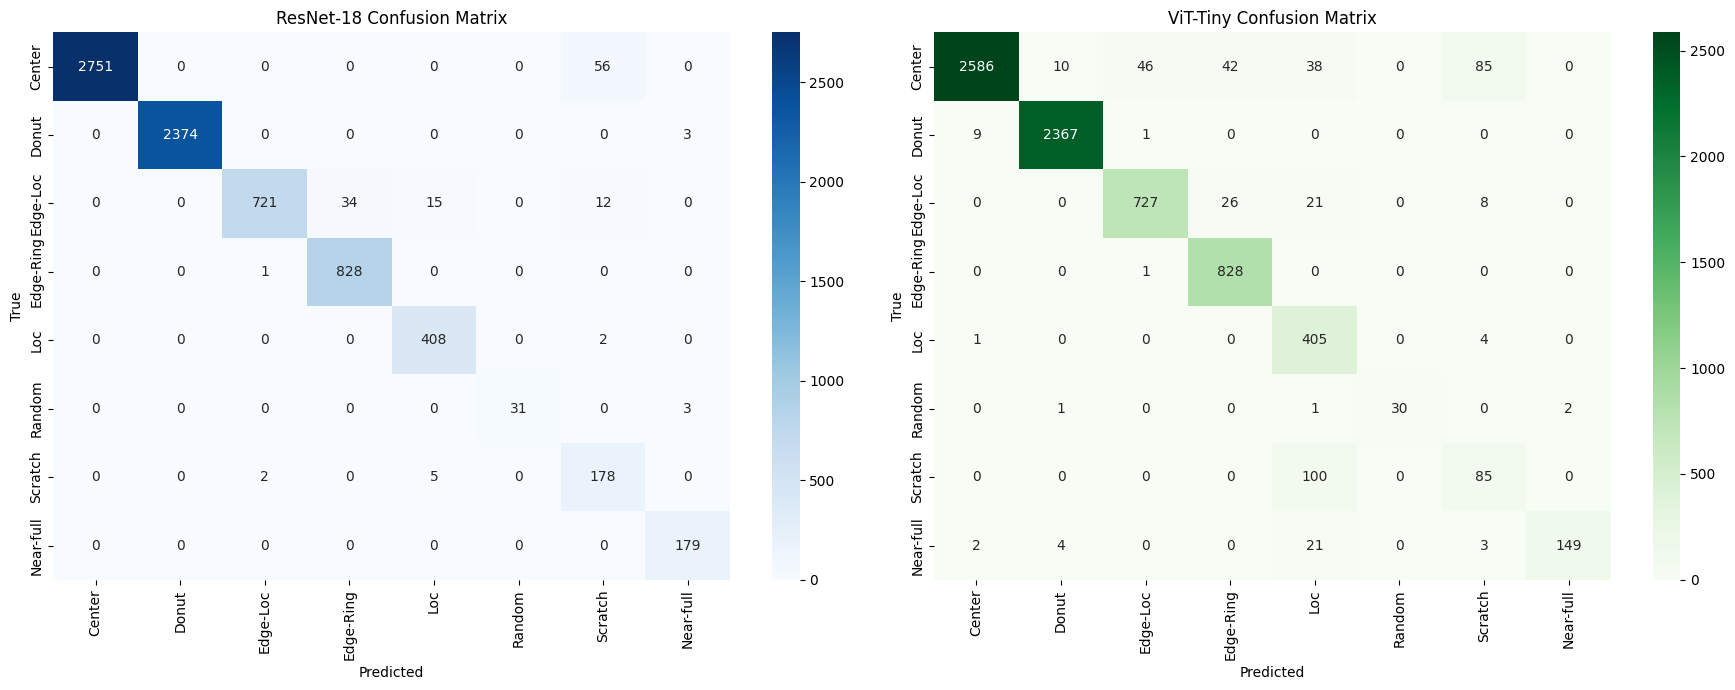

In [ ]:
# ============================================================
# FINAL EVALUATION: REPORTS & CONFUSION MATRICES
# ============================================================
# We compare:
#   - ResNet-18 (from scratch)
#   - ViT-Tiny (pre-trained, fine-tuned)
# on the held-out test set.

CLASS_NAMES = [
    "Center", "Donut", "Edge-Loc", "Edge-Ring",
    "Loc", "Random", "Scratch", "Near-full"
]


def get_predictions(model, loader, device=DEVICE):
    """Run inference on a model and return (targets, predictions)."""
    model.eval()
    all_targets = []
    all_preds = []

    with torch.no_grad():
        for imgs, targets in loader:
            imgs = imgs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)

            all_targets.extend(targets.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())

    return np.array(all_targets), np.array(all_preds)



resnet_best = resnet18(weights=None)
in_features = resnet_best.fc.in_features
resnet_best.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(in_features, NUM_CLASSES),
)
resnet_best.load_state_dict(
    torch.load("resnet18_wafer_tuned_best.pth", map_location=DEVICE)
)
resnet_best = resnet_best.to(DEVICE)


vit_best = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=False,
    num_classes=NUM_CLASSES,
)
vit_best.load_state_dict(
    torch.load("vit_tiny_wafer_best.pth", map_location=DEVICE)
)
vit_best = vit_best.to(DEVICE)


y_true_resnet, y_pred_resnet = get_predictions(resnet_best, test_loader)
y_true_vit, y_pred_vit = get_predictions(vit_best, test_loader)


print("=== ResNet-18 Classification Report ===")
print(classification_report(y_true_resnet, y_pred_resnet, target_names=CLASS_NAMES))

print("\n=== ViT-Tiny Classification Report ===")
print(classification_report(y_true_vit, y_pred_vit, target_names=CLASS_NAMES))

cm_resnet = confusion_matrix(y_true_resnet, y_pred_resnet)
cm_vit    = confusion_matrix(y_true_vit,    y_pred_vit)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    cm_resnet, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0]
)
axes[0].set_title("ResNet-18 Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(
    cm_vit, annot=True, fmt="d", cmap="Greens",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1]
)
axes[1].set_title("ViT-Tiny Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()


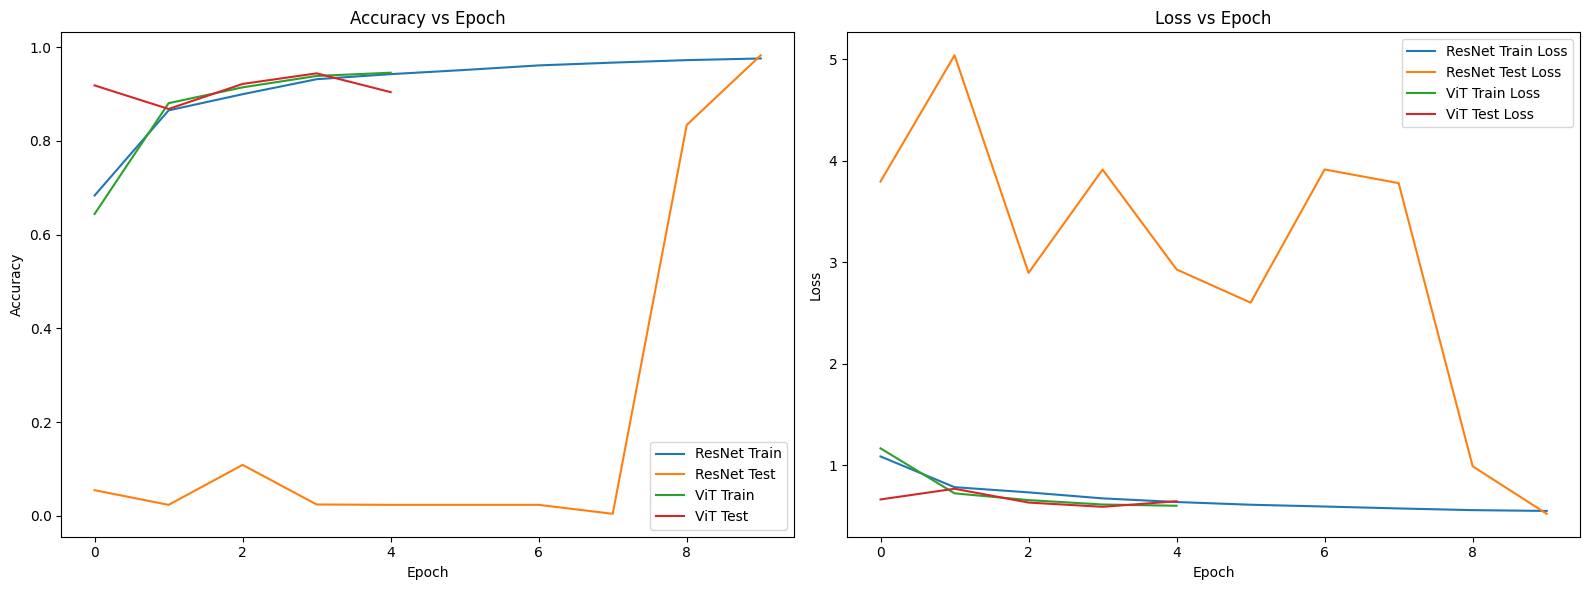

In [ ]:
# ============================================================
# TRAINING CURVES: RESNET vs VIT
# ============================================================

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(history_resnet["train_acc"], label="ResNet Train")
plt.plot(history_resnet["test_acc"], label="ResNet Test")
plt.plot(history_vit["train_acc"], label="ViT Train")
plt.plot(history_vit["test_acc"], label="ViT Test")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_resnet["train_loss"], label="ResNet Train Loss")
plt.plot(history_resnet["test_loss"], label="ResNet Test Loss")
plt.plot(history_vit["train_loss"], label="ViT Train Loss")
plt.plot(history_vit["test_loss"], label="ViT Test Loss")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


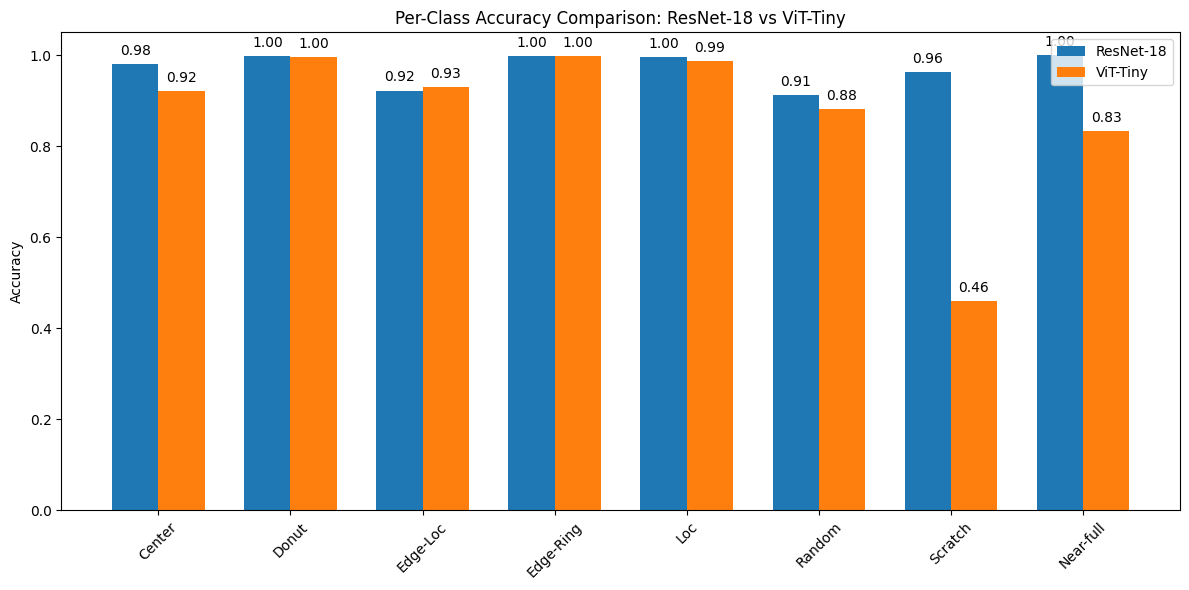

In [ ]:
# ============================================================
# PER-CLASS ACCURACY BAR CHART (ResNet vs ViT)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_resnet = confusion_matrix(y_true_resnet, y_pred_resnet)
cm_vit    = confusion_matrix(y_true_vit,    y_pred_vit)

acc_resnet = cm_resnet.diagonal() / cm_resnet.sum(axis=1)
acc_vit    = cm_vit.diagonal() / cm_vit.sum(axis=1)

x = np.arange(len(CLASS_NAMES))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, acc_resnet, width, label='ResNet-18')
plt.bar(x + width/2, acc_vit,    width, label='ViT-Tiny')

plt.xticks(x, CLASS_NAMES, rotation=45)
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy Comparison: ResNet-18 vs ViT-Tiny")
plt.legend()

for i, v in enumerate(acc_resnet):
    plt.text(i - width/2, v + 0.02, f"{v:.2f}", ha='center')
for i, v in enumerate(acc_vit):
    plt.text(i + width/2, v + 0.02, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()


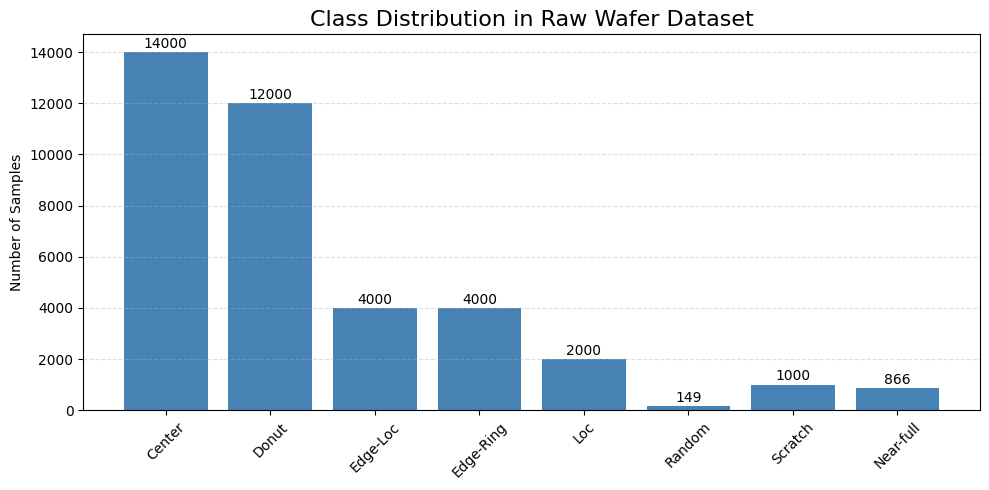

In [ ]:
# ============================================================
# CLASS IMBALANCE BAR CHART (Original Dataset)
# ============================================================

CLASS_NAMES = [
    "Center", "Donut", "Edge-Loc", "Edge-Ring",
    "Loc", "Random", "Scratch", "Near-full"
]

y_all_primary = np.argmax(labels, axis=1)

counts = Counter(y_all_primary)

plt.figure(figsize=(10, 5))
bars = plt.bar(CLASS_NAMES, [counts[i] for i in range(8)], color="steelblue")

plt.title("Class Distribution in Raw Wafer Dataset", fontsize=16)
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 50, str(height),
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()